In [26]:
from dace_query.sun import Sun

from astropy.io import fits
from astropy.time import Time
from astropy.timeseries import LombScargle

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

from scipy.optimize import curve_fit
import scipy.stats as ss
from sklearn.decomposition import PCA

import re  # find pattern in string
from tqdm import tqdm  # progress bar
import logging  # to avoid printing too many warnings

import tools as t

In [2]:
# get RV data of the Sun
# from Dace tutorial: https://dace.unige.ch/pythonAPI/?tutorialId=800
data_original = Sun.query_database(output_format="pandas", limit=200000)
to_keep = data_original.spectro_drs_qc == 1
data_ccf = data_original[to_keep]

In [3]:
# extract time and radial velocity from the data
time   = data_ccf.obj_date_bjd  # Barycentric Julian Date
rv_sun = data_ccf.spectro_ccf_rv  # m/s

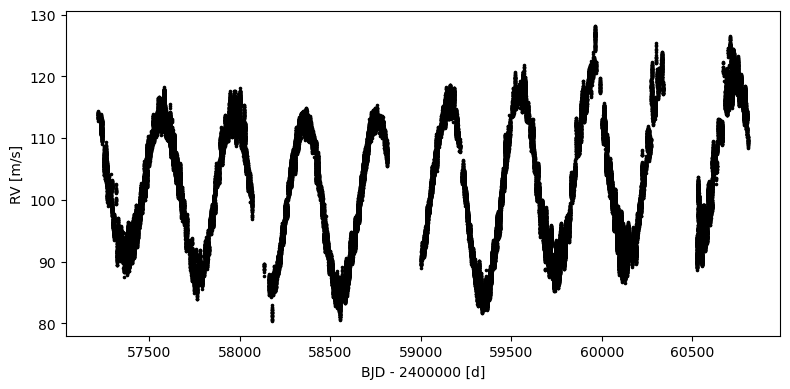

In [4]:
# plot the raw radial velocities, in the Solar System barycenter rest frame
plt.figure(figsize=(8, 4))
plt.scatter(time, rv_sun, marker='.', s=10, color='k')
plt.xlabel('BJD - 2400000 [d]')
plt.ylabel('RV [m/s]')
plt.tight_layout()

In [5]:
# perform fit
# initial guess for P is the synodic period of Jupiter
fit = curve_fit(t.RV_jup, time, rv_sun, p0=[1, 1, 398, 1, 1])
A_0 , A_1, P, phi, C = fit[0]

In [6]:
# create time array to plot the fit as a function of it
time_fit = np.linspace(min(time), max(time), 500)

# calculate the sinusoidal function for the time array
rv_sun_fit = np.array([])
for i in time_fit:
    y = t.RV_jup(i, A_0, A_1, P, phi, C)
    rv_sun_fit = np.append(rv_sun_fit, y)

# calculate residuals
res = rv_sun - t.RV_jup(time, A_0 , A_1, P, phi, C)

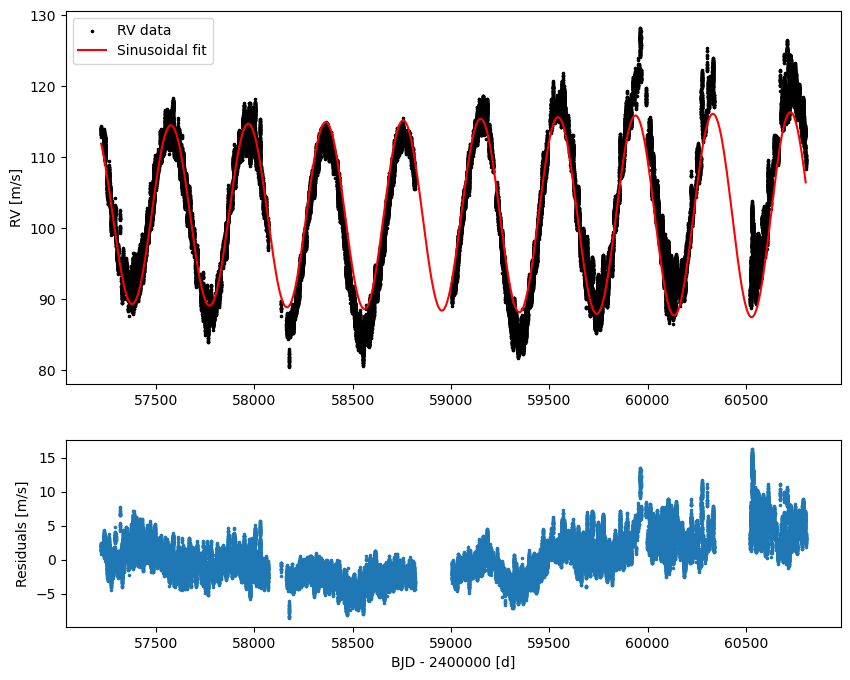

In [7]:
# plot data and fit
fig, axs = plt.subplots(2, 1, figsize=(10, 8), height_ratios=[2, 1])
axs[0].scatter(time, rv_sun, marker='.', s=10, color='k', label='RV data')
axs[0].plot(time_fit, rv_sun_fit, color='red', label='Sinusoidal fit')
axs[0].set_ylabel('RV [m/s]')
axs[0].legend()
axs[1].scatter(time, res, marker='.', s=10)
axs[1].set_xlabel('BJD - 2400000 [d]')
axs[1].set_ylabel('Residuals [m/s]')
plt.show()

## Spectra

In [8]:
# get data corresponding to 2019 and 2022

path_dace = '../data/dace_sun/'  # define the path of the directory where the data is saved

# maximum one file per day
data_spec = data_ccf[data_ccf['date_night'] < '2019']  # end date
data_spec = data_spec['2015' < data_spec['date_night']]  # start date
data_spec = data_spec.sort_values('obj_date_bjd')  # sort
dates_ccf = data_spec['date_night'].to_numpy()  # observation dates (just date, not time)
files_ccf = data_spec['file_rootpath'].to_numpy()  # file names
dates_ccf

array(['2015-07-16', '2015-07-16', '2015-07-16', ..., '2018-12-31',
       '2018-12-31', '2018-12-31'], shape=(41513,), dtype=object)

In [9]:
# load absorption bands
bands = np.genfromtxt('../data/bands.txt', dtype=None, encoding=None, names=True, delimiter=',')

In [10]:
# extract data from saved files
# example for one file
filename = path_dace + '2015-2018/2015-07-29/r.HARPN.2015-07-29T10-44-34.947_S1D_A.fits'
s1d = fits.getdata(filename, 1)  # load file
wl = s1d['wavelength_air']  # angstrom
s1d.columns

ColDefs(
    name = 'wavelength'; format = '1D'; unit = 'angstrom'
    name = 'wavelength_air'; format = '1D'; unit = 'angstrom'
    name = 'flux'; format = '1D'; unit = 'e-'
    name = 'error'; format = '1D'; unit = 'e-'
    name = 'quality'; format = '1J'
)

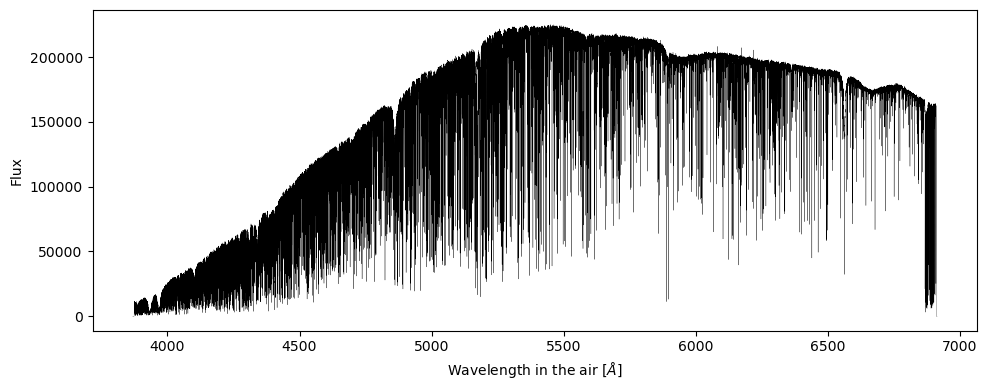

In [11]:
# plot spectrum
plt.figure(figsize=(10, 4))
plt.plot(wl, s1d['flux'], linewidth=.2, color='k')
plt.xlabel(r'Wavelength in the air [$\AA$]')
plt.ylabel('Flux')
plt.tight_layout()

In [12]:
# iterate over saved files from 2017 to 2018
# save names (observation dates) of the files
dates_files = []
for entry in os.scandir(path_dace + '2015-2018'):
    if entry.name != 'spectra.txt':
        dates_files.append(entry.name)

dates_files = sorted(dates_files, key=lambda d: datetime.strptime(d, "%Y-%m-%d"))  # sort
print(dates_files)

['2015-07-29', '2015-07-30', '2015-07-31', '2015-08-01', '2015-08-02', '2015-08-03', '2015-08-04', '2015-08-05', '2015-08-07', '2015-08-16', '2015-08-17', '2015-08-18', '2015-08-19', '2015-08-20', '2015-08-21', '2015-08-22', '2015-08-25', '2015-08-26', '2015-08-27', '2015-08-28', '2015-08-29', '2015-08-30', '2015-08-31', '2015-09-01', '2015-09-02', '2015-09-03', '2015-09-04', '2015-09-05', '2015-09-07', '2015-09-13', '2015-09-14', '2015-09-15', '2015-09-16', '2015-09-17', '2015-09-20', '2015-09-27', '2015-09-28', '2015-10-06', '2015-10-08', '2015-10-10', '2015-10-11', '2015-10-12', '2015-10-26', '2015-10-28', '2015-10-29', '2015-10-30', '2015-11-01', '2015-11-02', '2015-11-03', '2015-11-04', '2015-11-05', '2015-11-06', '2015-11-07', '2015-11-08', '2015-11-14', '2015-11-18', '2015-11-20', '2015-11-21', '2015-11-23', '2015-11-24', '2015-11-26', '2015-11-28', '2015-12-11', '2015-12-12', '2015-12-15', '2015-12-21', '2015-12-22', '2015-12-23', '2015-12-24', '2015-12-25', '2015-12-28', '2015

In [13]:
# make a list of the available files that end by A.fits
files_list = []
for d in dates_files:  # iterate over directories
    date_path = f'{path_dace}2015-2018/{d}/'
    files = os.scandir(date_path)  # files in directory
    files = list(files)
    files = [d + '/' + i.name for i in files]  # list of file names
    files_list.extend(files)  # save file names
files_list = [s for s in files_list if s.endswith('A.fits')]  # keep only the files that end by A.fits
files_list = np.array(files_list)
len(files_list)

1254

In [14]:
# save spectra in matrix rows
# the row i from spectra contains the spectrum from the file i from files_list
spectra = []
err = []
for f in files_list:  # iterate over files
    file_path = path_dace + '2015-2018/' + f
    hdul = fits.open(file_path)  # open file
    spectra.append(hdul[1].data['flux'])  # save spectrum
    err.append(hdul[1].data['error'])  # save flux error
            
spectra = np.array(spectra)
err = np.array(err)
print(spectra.shape, err.shape)

(1254, 212207) (1254, 212207)


In [15]:
# get corresponding RV data
# extract datetime from file names (file_rootpath) in data_spec
pattern = re.compile(r"\d{4}-\d{2}-\d{2}T\d{2}-\d{2}-\d{2}\.\d+")  # pattern to look for in the files names

times_files = {}  # datetime string: ccf file name
for sequence in files_ccf:  # iterate over files names
    time_str = t.extract_pattern(sequence, pattern)  # get the observation time from the file's name
    if time_str:
        times_files[time_str] = sequence

measure_times = sorted(list(times_files.keys()))  # sorted observation times
print(len(measure_times))

# find files in file_list (downloaded spectra) that have a corresponding ccf file
matches = []  # contains tuples of the form: (name_of_spectrum_file, name_of_ccf_file)
times = []  # list of datetime objects corresponding to the files that are actually used

for sequence in files_list:  # iterate over files names
    time_str = t.extract_pattern(sequence, pattern)  # get the observation time from the file's name
    if time_str in times_files:
        matches.append((sequence, times_files[time_str]))
        times.append(datetime.strptime(time_str, '%Y-%m-%dT%H-%M-%S.%f'))

matches = np.array(matches)
times = np.array(sorted(times))
times_jd = np.array([Time(i).jd for i in times])  # convert to Julian Date to simplify some plots

41513


In [16]:
# RV data from data_spec recovered from the rows where the column 'file_rootpath' is in the list of matches
RV_list = data_spec[data_spec['file_rootpath'].isin(matches[:, 1])]['spectro_ccf_rv'].to_numpy()
len(RV_list)

1254

In [17]:
# extract wavelength (same for all files)
# example for one file
filename = path_dace + '2015-2018/' + files_list[0]
s1d = fits.getdata(filename, 1)  # load file
wl = s1d['wavelength_air']  # angstrom

# mean spectrum
mean_spec = np.mean(spectra, axis=0)  # calculate mean spectrum (i.e. the mean flux for each wl)
# take out projection over the velocity vector
S_f, D = t.subtract_v(wl, spectra, c=3e8)  # speed of light in m/s

# apply double centering to the spectra matrix
spectra_centered = t.double_centering(S_f)

In [18]:
# apply PCA to the centered spectra matrix
n_components = 40
pca_flux = PCA(n_components=n_components)  # create PCA object
pcs  = pca_flux.fit_transform(spectra_centered)  # fit the model with spectra_centered and apply the dimensionality reduction
var  = pca_flux.explained_variance_ratio_
print(f'Variance explained by the {n_components} components:', var)  # how much information (variance) can be attributed to each of the principal components

Variance explained by the 40 components: [9.99999994e-01 5.06838811e-09 3.02139749e-10 1.86051017e-10
 1.75868966e-10 6.54578087e-11 2.00999984e-11 1.77323190e-11
 1.30708165e-11 4.65236007e-12 1.50193482e-12 1.06280755e-12
 5.12742351e-13 4.64514848e-13 3.00701345e-13 2.82836173e-13
 2.65868603e-13 2.23654217e-13 1.27151079e-13 8.73056915e-14
 6.03104026e-14 4.92207958e-14 4.32737952e-14 4.16133776e-14
 3.78630400e-14 3.76438349e-14 3.47133314e-14 3.27509126e-14
 3.17350468e-14 3.13103861e-14 3.08369761e-14 2.98661061e-14
 2.79534922e-14 2.70803385e-14 2.66719108e-14 2.52245921e-14
 2.45343466e-14 2.31985091e-14 2.28330431e-14 2.26094731e-14]


In [ ]:
# save loadings and scores
loadings = pca_flux.components_
scores = np.array([pcs[:, i] for i in range(n_components)])

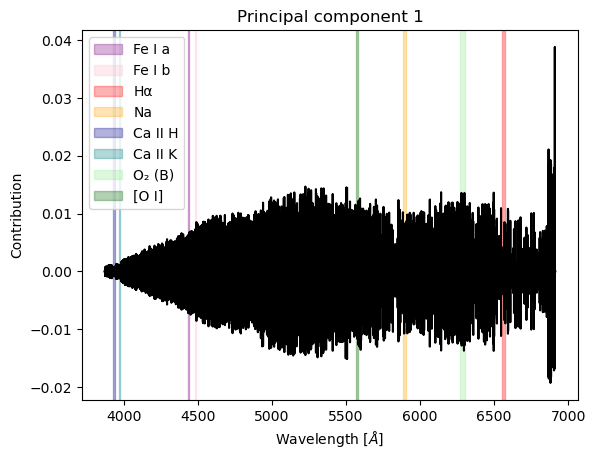

In [20]:
# plot loadings
# plot shows how much each wavelength value (feature) contributes to the variance of a PC
for i in range(1):  # put n_components instead of 1 to see all the plots
    plt.plot(wl, pca_flux.components_[i], color='k')
    for j in bands:
        plt.axvspan(xmin=j['start']*10, xmax=j['end']*10, color=j['color'], label=j['name'], alpha=.3)
    plt.title(f'Principal component {i + 1}', size=12)
    plt.xlabel(r'Wavelength [$\AA$]')
    plt.ylabel('Contribution')
    plt.legend()
    plt.show()

In [23]:
# Periodograms (Lomb-Scargle because the timestep between observations is irregular)
# https://docs.astropy.org/en/latest/timeseries/lombscargle.html

periodograms = [LombScargle(times_jd, pcs[:, i]).autopower() for i in range(n_components)]

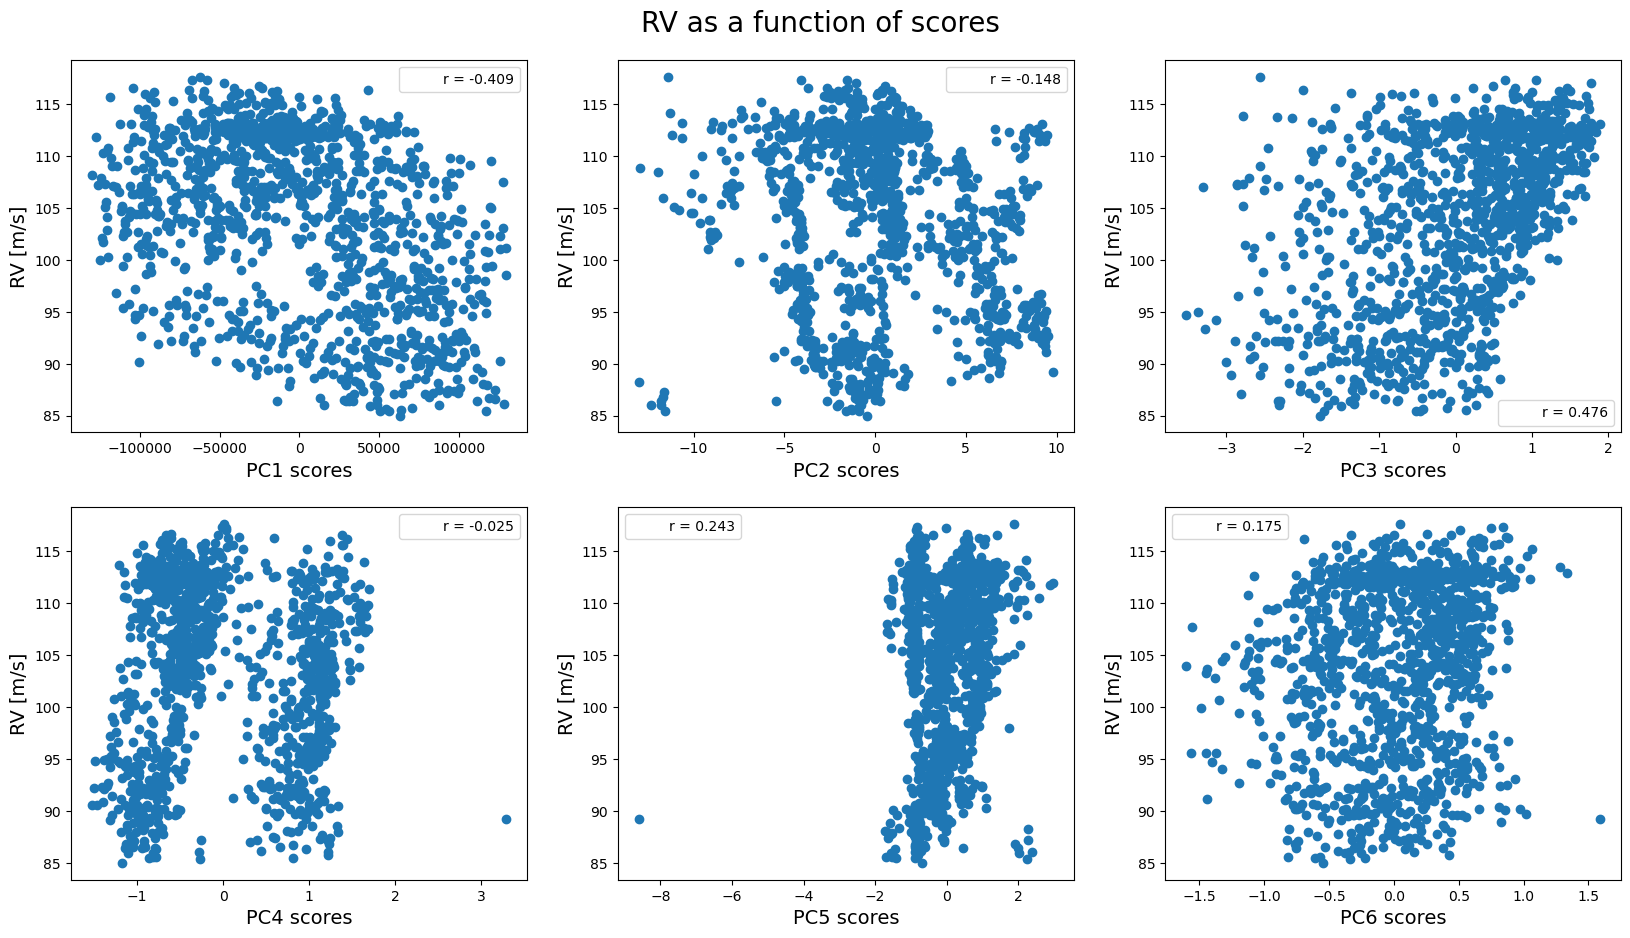

In [27]:
# RV as a function of scores

rows = 2
cols = 3
fig, axs = plt.subplots(rows, cols, figsize=(20, 10))
fig.suptitle('RV as a function of scores', size=20)

r = -1
k = 0
for i in range(6):
    if i % cols == 0:
        r += 1  # advance to the next column
        k = 0  # reset row
    # RV as a function of scores
    axs[r][k].scatter(scores[i], RV_list)
    axs[r][k].axvline(0, color='w', label=f'r = {ss.pearsonr(scores[i], RV_list)[0]:.3f}', zorder=-1)
    axs[r][k].set_xlabel(f'PC{i+1} scores', size=14)
    axs[r][k].set_ylabel('RV [m/s]', size=14)
    axs[r][k].legend()
    k += 1

plt.subplots_adjust(top=.93)
plt.show()

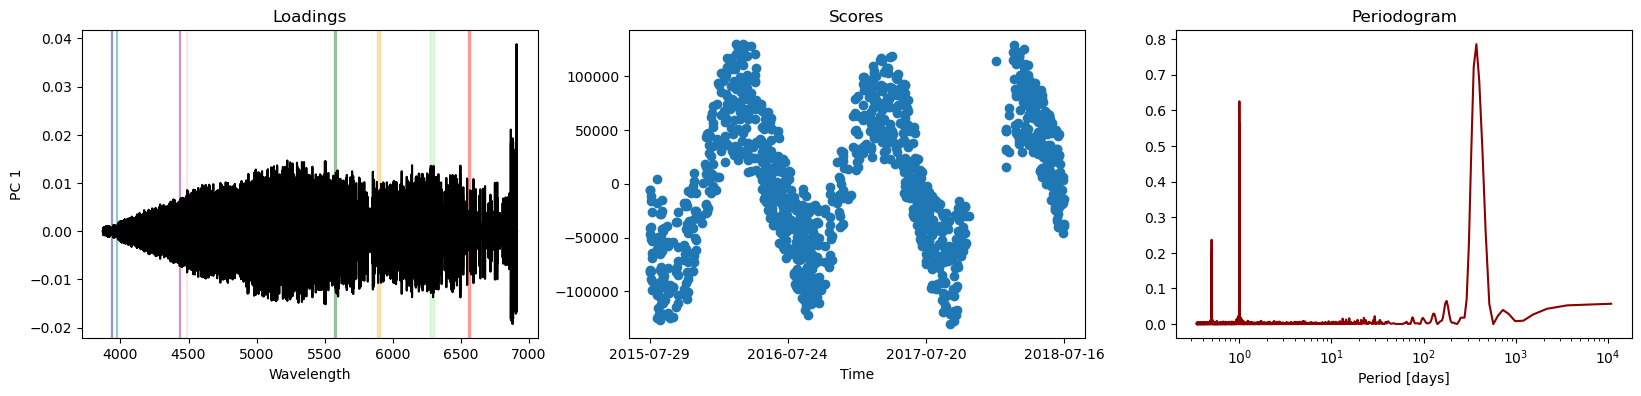

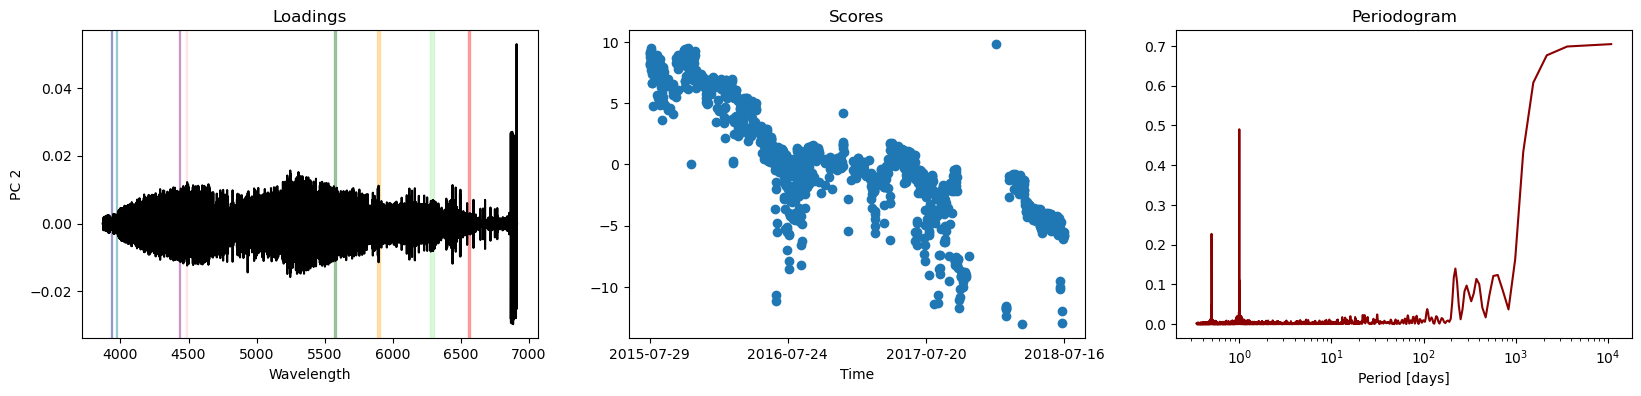

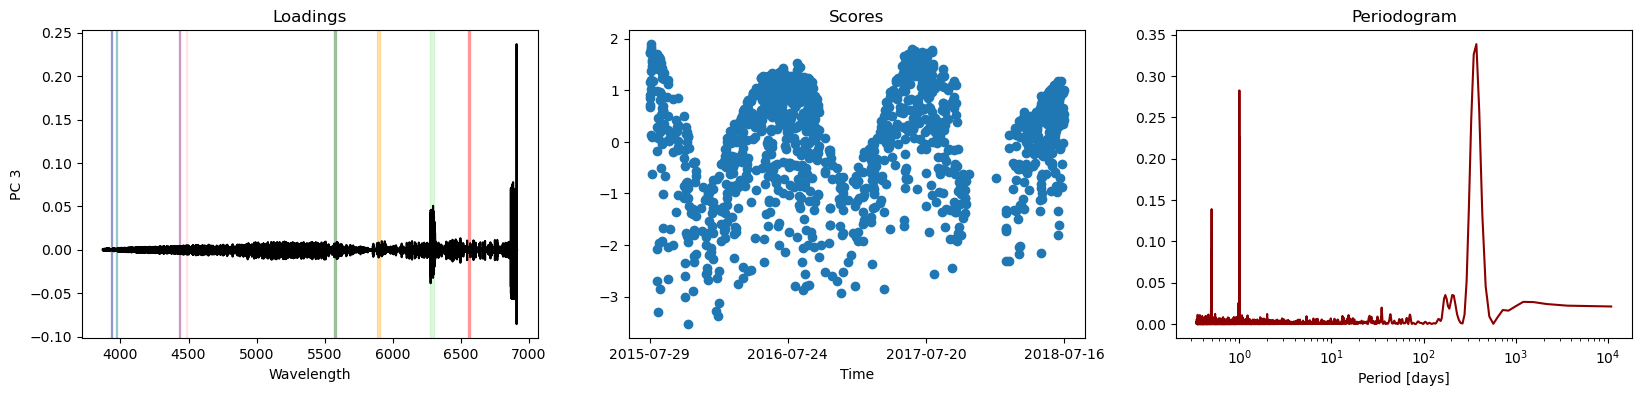

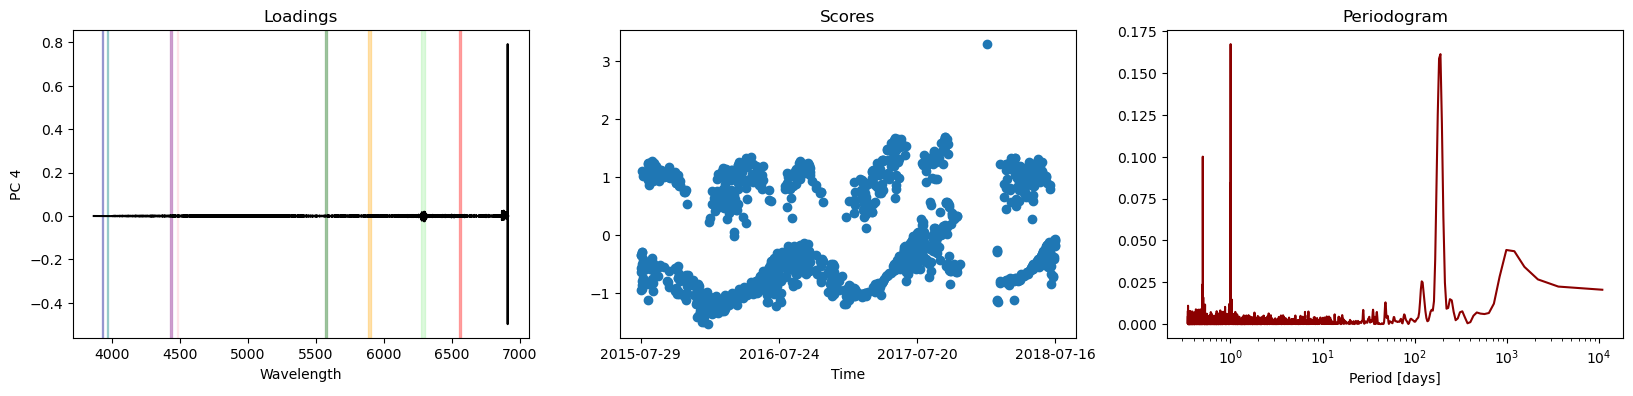

In [28]:
# plot
for i in range(n_components // 10):
    fig, axs = plt.subplots(1, 3, figsize=(20, 4))
    
    # Loadings
    axs[0].plot(wl, pca_flux.components_[i], color='k')
    for j in bands:
        axs[0].axvspan(xmin=j['start']*10, xmax=j['end']*10, color=j['color'], label=j['name'], alpha=.3)
    axs[0].set_title('Loadings', size=12)
    axs[0].set_xlabel('Wavelength')
    axs[0].set_ylabel(f'PC {i + 1}')
    
    # Scores
    axs[1].scatter(times, pcs[:, i])
    axs[1].set_title('Scores', size=12)
    axs[1].set_xlabel('Time')
    axs[1].set_xticks(np.linspace(times[0], times[-1], 4))

    # periodogram
    axs[2].plot(1 / periodograms[i][0], periodograms[i][1], color='darkred')
    axs[2].set_xscale('log')
    axs[2].set_title('Periodogram', size=12)
    axs[2].set_xlabel('Period [days]')
    
    plt.show()